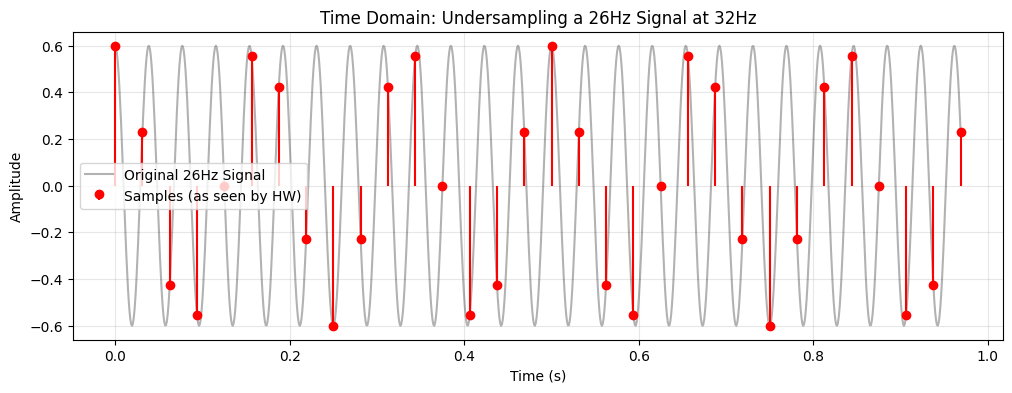

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fft_utils import run_sim

# Parameters
N = 32          # HW FFT size
fs = 32         # Sampling frequency (Hz)
f_sig = 26      # Signal frequency (Hz) -> VIOLATES NYQUIST (fs/2 = 16Hz)

# 1. Generate "Continuous" signal (for display) and "Sampled" signal (for HW)
t_cont = np.linspace(0, (N-1)/fs, 1000)
sig_cont = 0.6 * np.cos(2 * np.pi * f_sig * t_cont)

t_sampled = np.arange(N) / fs
sig_sampled = 0.6 * np.cos(2 * np.pi * f_sig * t_sampled)

# Plotting
plt.figure(figsize=(12, 4))
plt.plot(t_cont, sig_cont, 'k-', alpha=0.3, label=f"Original {f_sig}Hz Signal")
plt.stem(t_sampled, sig_sampled, linefmt='r-', markerfmt='ro', basefmt=' ', label="Samples (as seen by HW)")
plt.title("Time Domain: Undersampling a 26Hz Signal at 32Hz")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- Starting Hardware Simulation (N=32) ---
     -.--ns INFO     gpi                                ..mbed/gpi_embed.cpp:93   in _embed_init_python              Using Python 3.11.9 interpreter at /home/harald/VHDL_FFT/.vhdl_env/bin/python3
     -.--ns INFO     gpi                                ../gpi/GpiCommon.cpp:79   in gpi_print_registered_impl       VHPI registered


** Note: loading VHPI plugin /home/harald/VHDL_FFT/.vhdl_env/lib/python3.11/site-packages/cocotb/libs/libcocotbvhpi_nvc.so


     0.00ns INFO     cocotb                             Running on nvc version 1.20-devel
     0.00ns WARNING  gpi                                VHPI: Other iterator types not implemented yet
     0.00ns INFO     cocotb                             Seeding Python random module with 1773174293
     0.00ns INFO     cocotb                             Initialized cocotb v2.0.1 from /home/harald/VHDL_FFT/.vhdl_env/lib/python3.11/site-packages/cocotb
     0.00ns INFO     cocotb                             Running tests
     0.00ns INFO     cocotb.regression                  running test_fft.run_hw_iteration (1/1)
  7880.00ns INFO     cocotb.regression                  test_fft.run_hw_iteration passed
  7880.00ns INFO     cocotb.regression                  **************************************************************************************
                                                        ** TEST                          STATUS  SIM TIME (ns)  REAL TIME (s)  RATIO (ns/s) **
          

** Note: 7880ns+1: VHPI plugin requested end of simulation


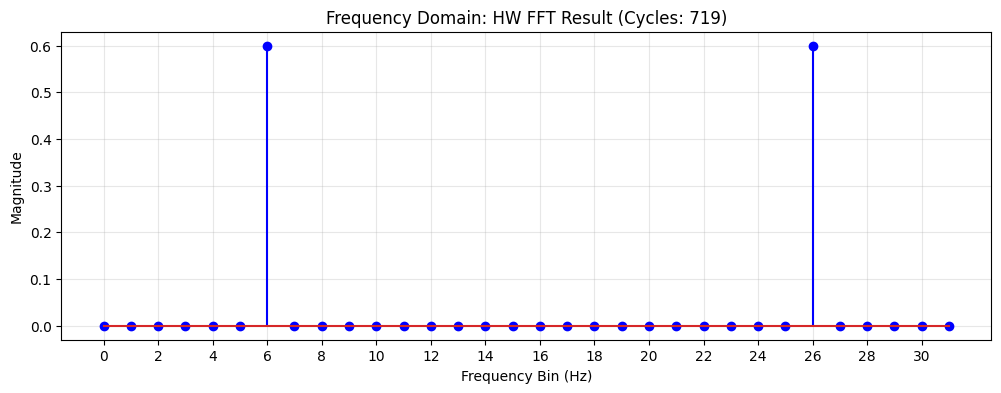

In [2]:
# 2. Run Hardware FFT
# We pass the sampled array directly to our new run_sim function
fft_hw, exp, cycles = run_sim(sig_sampled, invert=False)

# Plotting the Spectrum
plt.figure(figsize=(12, 4))
freqs = np.arange(N)
plt.stem(freqs, np.abs(fft_hw), linefmt='b-', markerfmt='bo')

# Annotate the alias
#plt.annotate('Alias Peak at 6Hz!', xy=(6, np.abs(fft_hw[6])), xytext=(10, 10),
#             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title(f"Frequency Domain: HW FFT Result (Cycles: {cycles})")
plt.xlabel("Frequency Bin (Hz)")
plt.ylabel("Magnitude")
plt.xticks(np.arange(0, N, 2))
plt.grid(True, alpha=0.3)
plt.show()

#print(f"Notice: The peak is at Bin 6, because |{f_sig} - {fs}| = 6.")

In [4]:
# 3. Run Hardware IFFT
# We pass the FFT result back into the hardware to reconstruct the time domain
# Note: Since our run_sim handles quantization, we pass the complex fft_hw
sig_reconstructed, exp, cycles_i = run_sim(fft_hw, invert=True)

# Plotting comparison
plt.figure(figsize=(12, 5))
plt.plot(t_cont, sig_cont, 'k--', alpha=0.3, label=f"Original {f_sig}Hz Signal (Reality)")
plt.plot(t_sampled, np.real(sig_reconstructed*2), 'r-o', linewidth=2, label="HW Reconstructed Signal (Alias)")

plt.title("The Aliasing Effect: Hardware vs. Reality")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

print(f"The red line is a 6Hz signal. The hardware is mathematically correct,")
print(f"but because we undersampled, the 26Hz signal is lost forever!")

--- Starting Hardware Simulation (N=128) ---
     -.--ns INFO     gpi                                ..mbed/gpi_embed.cpp:93   in _embed_init_python              Using Python 3.11.9 interpreter at /home/harald/VHDL_FFT/.vhdl_env/bin/python3
     -.--ns INFO     gpi                                ../gpi/GpiCommon.cpp:79   in gpi_print_registered_impl       VHPI registered


** Note: loading VHPI plugin /home/harald/VHDL_FFT/.vhdl_env/lib/python3.11/site-packages/cocotb/libs/libcocotbvhpi_nvc.so


     0.00ns INFO     cocotb                             Running on nvc version 1.20-devel
     0.00ns WARNING  gpi                                VHPI: Other iterator types not implemented yet
     0.00ns INFO     cocotb                             Seeding Python random module with 1773350580
     0.00ns INFO     cocotb                             Initialized cocotb v2.0.1 from /home/harald/VHDL_FFT/.vhdl_env/lib/python3.11/site-packages/cocotb
     0.00ns INFO     cocotb                             Running tests
     0.00ns INFO     cocotb.regression                  running test_fft.run_hw_iteration (1/1)
 42920.00ns INFO     cocotb.regression                  test_fft.run_hw_iteration passed
 42920.00ns INFO     cocotb.regression                  **************************************************************************************
                                                        ** TEST                          STATUS  SIM TIME (ns)  REAL TIME (s)  RATIO (ns/s) **
          

** Note: 42920ns+1: VHPI plugin requested end of simulation


NameError: name 't_cont' is not defined

<Figure size 1200x500 with 0 Axes>

Running Forward HW FFT (N=128)...
--- Starting Hardware Simulation (N=128) ---


** Note: loading VHPI plugin /home/harald/VHDL_FFT/.vhdl_env/lib/python3.11/site-packages/cocotb/libs/libcocotbvhpi_nvc.so


     -.--ns INFO     gpi                                ..mbed/gpi_embed.cpp:93   in _embed_init_python              Using Python 3.11.9 interpreter at /home/harald/VHDL_FFT/.vhdl_env/bin/python3
     -.--ns INFO     gpi                                ../gpi/GpiCommon.cpp:79   in gpi_print_registered_impl       VHPI registered
     0.00ns INFO     cocotb                             Running on nvc version 1.20-devel
     0.00ns WARNING  gpi                                VHPI: Other iterator types not implemented yet
     0.00ns INFO     cocotb                             Seeding Python random module with 1773350570
     0.00ns INFO     cocotb                             Initialized cocotb v2.0.1 from /home/harald/VHDL_FFT/.vhdl_env/lib/python3.11/site-packages/cocotb
     0.00ns INFO     cocotb                             Running tests
     0.00ns INFO     cocotb.regression                  running test_fft.run_hw_iteration (1/1)
 42920.00ns INFO     cocotb.regression                  

** Note: 42920ns+1: VHPI plugin requested end of simulation


Running Inverse HW FFT (N=128)...
--- Starting Hardware Simulation (N=128) ---


** Note: loading VHPI plugin /home/harald/VHDL_FFT/.vhdl_env/lib/python3.11/site-packages/cocotb/libs/libcocotbvhpi_nvc.so


     -.--ns INFO     gpi                                ..mbed/gpi_embed.cpp:93   in _embed_init_python              Using Python 3.11.9 interpreter at /home/harald/VHDL_FFT/.vhdl_env/bin/python3
     -.--ns INFO     gpi                                ../gpi/GpiCommon.cpp:79   in gpi_print_registered_impl       VHPI registered
     0.00ns INFO     cocotb                             Running on nvc version 1.20-devel
     0.00ns WARNING  gpi                                VHPI: Other iterator types not implemented yet
     0.00ns INFO     cocotb                             Seeding Python random module with 1773350572
     0.00ns INFO     cocotb                             Initialized cocotb v2.0.1 from /home/harald/VHDL_FFT/.vhdl_env/lib/python3.11/site-packages/cocotb
     0.00ns INFO     cocotb                             Running tests
     0.00ns INFO     cocotb.regression                  running test_fft.run_hw_iteration (1/1)
 42920.00ns INFO     cocotb.regression                  

** Note: 42920ns+1: VHPI plugin requested end of simulation


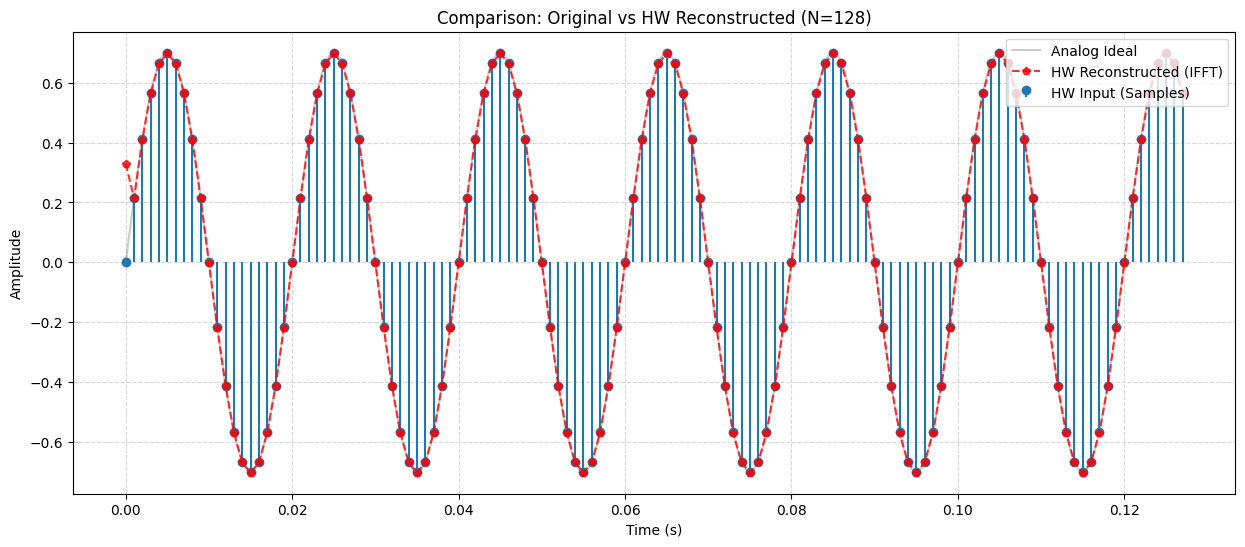

Mean Squared Error: 6.20e-02


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from fft_utils import run_sim 

# 1. Increase N for a smoother look
N = 128          # Hardware will re-compile for 128 points
fs = 1000        # 1kHz Sampling rate
f_sig = 50       # 50Hz Signal (fits 6.4 times in this window)

# Create a smooth time vector for the "Ideal" wave
t_fine = np.linspace(0, (N-1)/fs, 1000)
sig_ideal = 0.7 * np.sin(2 * np.pi * f_sig * t_fine)

# Create the sampled vector for the HW
t_sampled = np.arange(N) / fs
input_sig = 0.7 * np.sin(2 * np.pi * f_sig * t_sampled).astype(complex)

# Leacage to the first sample can be fixed by centering the wave
#f_centered = (6 * 1000) / 128
#input_sig = 0.7 * np.sin(2 * np.pi * f_centered * t_sampled).astype(complex)

# --- Step 1: Forward FFT ---
print(f"Running Forward HW FFT (N={N})...")
fft_hw, e, _ = run_sim(input_sig, invert=False)

# --- Step 2: Inverse FFT ---
print(f"Running Inverse HW FFT (N={N})...")
reconstructed_sig, e2, _ = run_sim(fft_hw, invert=True)

# 2. Plotting for comparison
plt.figure(figsize=(15, 6))

# Plot the "Continuous" ideal wave for reference
plt.plot(t_fine, sig_ideal, 'k-', alpha=0.2, label='Analog Ideal')

# Plot the points the Hardware actually processed
plt.stem(t_sampled, input_sig.real, linefmt='C0-', markerfmt='C0o', 
         label='HW Input (Samples)', basefmt=" ")

# Plot what came back out of the IFFT
plt.plot(t_sampled, reconstructed_sig.real*(2**(e+e2)/N), 'r--p', alpha=0.8, 
         label='HW Reconstructed (IFFT)')

plt.title(f"Comparison: Original vs HW Reconstructed (N={N})")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend(loc='upper right')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

# 3. Check for the "Missing" Signal
mse = np.mean(np.abs(input_sig - reconstructed_sig)**2)
print(f"Mean Squared Error: {mse:.2e}")

--- Starting Hardware Simulation (N=128) ---
     -.--ns INFO     gpi                                ..mbed/gpi_embed.cpp:93   in _embed_init_python              Using Python 3.11.9 interpreter at /home/harald/VHDL_FFT/.vhdl_env/bin/python3
     -.--ns INFO     gpi                                ../gpi/GpiCommon.cpp:79   in gpi_print_registered_impl       VHPI registered


** Note: loading VHPI plugin /home/harald/VHDL_FFT/.vhdl_env/lib/python3.11/site-packages/cocotb/libs/libcocotbvhpi_nvc.so


     0.00ns INFO     cocotb                             Running on nvc version 1.20-devel
     0.00ns WARNING  gpi                                VHPI: Other iterator types not implemented yet
     0.00ns INFO     cocotb                             Seeding Python random module with 1773351768
     0.00ns INFO     cocotb                             Initialized cocotb v2.0.1 from /home/harald/VHDL_FFT/.vhdl_env/lib/python3.11/site-packages/cocotb
     0.00ns INFO     cocotb                             Running tests
     0.00ns INFO     cocotb.regression                  running test_fft.run_hw_iteration (1/1)
 42920.00ns INFO     cocotb.regression                  test_fft.run_hw_iteration passed
 42920.00ns INFO     cocotb.regression                  **************************************************************************************
                                                        ** TEST                          STATUS  SIM TIME (ns)  REAL TIME (s)  RATIO (ns/s) **
          

** Note: 42920ns+1: VHPI plugin requested end of simulation


--- Starting Hardware Simulation (N=128) ---
     -.--ns INFO     gpi                                ..mbed/gpi_embed.cpp:93   in _embed_init_python              Using Python 3.11.9 interpreter at /home/harald/VHDL_FFT/.vhdl_env/bin/python3
     -.--ns INFO     gpi                                ../gpi/GpiCommon.cpp:79   in gpi_print_registered_impl       VHPI registered


** Note: loading VHPI plugin /home/harald/VHDL_FFT/.vhdl_env/lib/python3.11/site-packages/cocotb/libs/libcocotbvhpi_nvc.so


     0.00ns INFO     cocotb                             Running on nvc version 1.20-devel
     0.00ns WARNING  gpi                                VHPI: Other iterator types not implemented yet
     0.00ns INFO     cocotb                             Seeding Python random module with 1773351770
     0.00ns INFO     cocotb                             Initialized cocotb v2.0.1 from /home/harald/VHDL_FFT/.vhdl_env/lib/python3.11/site-packages/cocotb
     0.00ns INFO     cocotb                             Running tests
     0.00ns INFO     cocotb.regression                  running test_fft.run_hw_iteration (1/1)
 42920.00ns INFO     cocotb.regression                  test_fft.run_hw_iteration passed
 42920.00ns INFO     cocotb.regression                  **************************************************************************************
                                                        ** TEST                          STATUS  SIM TIME (ns)  REAL TIME (s)  RATIO (ns/s) **
          

** Note: 42920ns+1: VHPI plugin requested end of simulation


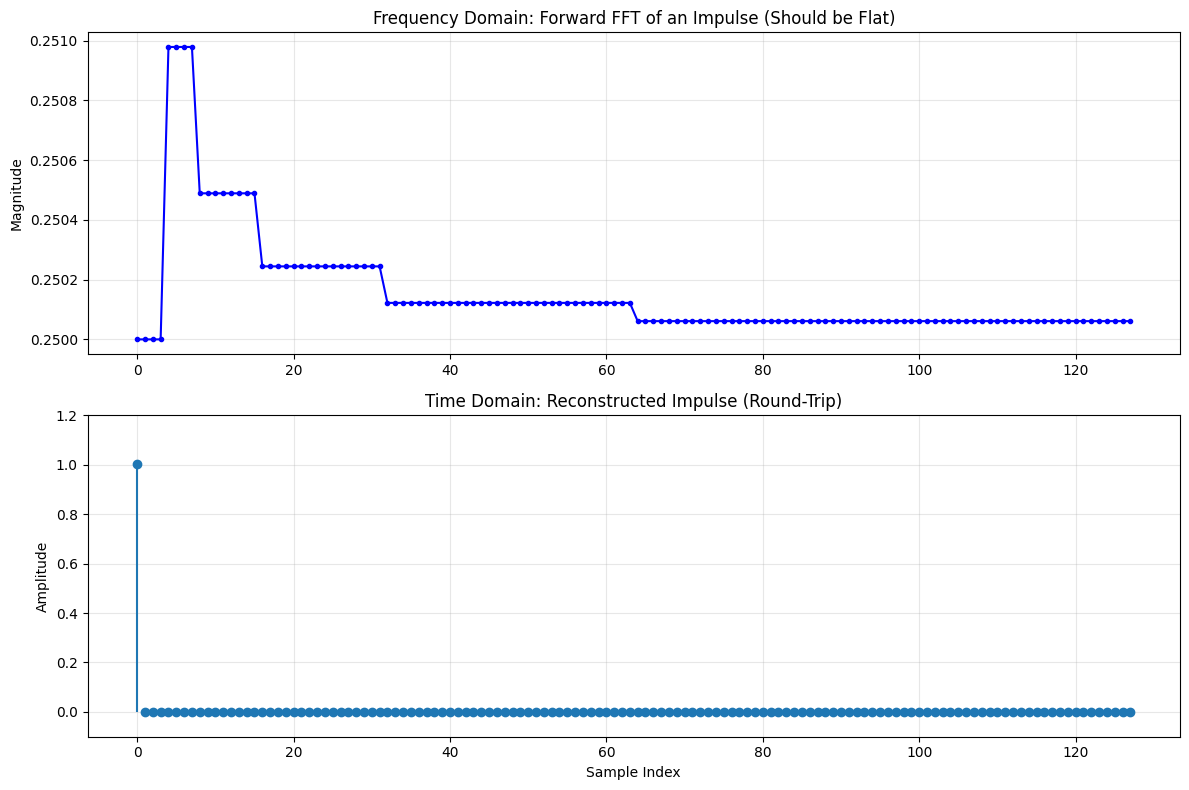

Sample 0 Amplitude: 1.0005
Sample 1 Amplitude: -0.0001


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from fft_utils import run_sim

# 1. Create the Impulse at Index 0
N = 128
input_sig = np.zeros(N, dtype=complex)
input_sig[0] = 1.0  # The "Impulse"

# --- Step 1: Forward FFT ---
# Expected: A flat magnitude across all bins
fft_hw, e1, _ = run_sim(input_sig, invert=False)

# --- Step 2: Inverse FFT ---
# Expected: The original [1, 0, 0, ...] impulse
reconstructed_sig, e2, _ = run_sim(fft_hw, invert=True)

# 2. Apply your Scaling Equation
# We multiply by 2**(e1+e2) and divide by N as per your manual correction
final_sig = (reconstructed_sig.real * (2.0**(e1 + e2))) / N

# 3. Plotting the results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Frequency Domain Plot
ax1.plot(np.abs(fft_hw), 'b-o', markersize=3)
ax1.set_title("Frequency Domain: Forward FFT of an Impulse (Should be Flat)")
ax1.set_ylabel("Magnitude")
ax1.grid(True, alpha=0.3)

# Time Domain Plot
ax2.stem(np.arange(N), final_sig, basefmt=" ")
ax2.set_title("Time Domain: Reconstructed Impulse (Round-Trip)")
ax2.set_xlabel("Sample Index")
ax2.set_ylabel("Amplitude")
ax2.set_ylim([-0.1, 1.2])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Sample 0 Amplitude: {final_sig[0]:.4f}")
print(f"Sample 1 Amplitude: {final_sig[1]:.4f}")

Running Hardware Simulation...


** Note: loading VHPI plugin /home/harald/VHDL_FFT/.vhdl_env/lib/python3.11/site-packages/cocotb/libs/libcocotbvhpi_nvc.so


     -.--ns INFO     gpi                                ..mbed/gpi_embed.cpp:93   in _embed_init_python              Using Python 3.11.9 interpreter at /home/harald/VHDL_FFT/.vhdl_env/bin/python3
     -.--ns INFO     gpi                                ../gpi/GpiCommon.cpp:79   in gpi_print_registered_impl       VHPI registered
     0.00ns INFO     cocotb                             Running on nvc version 1.20-devel
     0.00ns WARNING  gpi                                VHPI: Other iterator types not implemented yet
     0.00ns INFO     cocotb                             Seeding Python random module with 1773352327
     0.00ns INFO     cocotb                             Initialized cocotb v2.0.1 from /home/harald/VHDL_FFT/.vhdl_env/lib/python3.11/site-packages/cocotb
     0.00ns INFO     cocotb                             Running tests
     0.00ns INFO     cocotb.regression                  running test_fft.run_hw_iteration (1/1)
 18610.00ns INFO     cocotb.regression                  

** Note: 18610ns+1: VHPI plugin requested end of simulation


✅ Success! Latency: 1728 clock cycles.
📊 SQNR: 65.71 dB (Higher is better)


FileNotFoundError: [Errno 2] No such file or directory: 'results.npz'

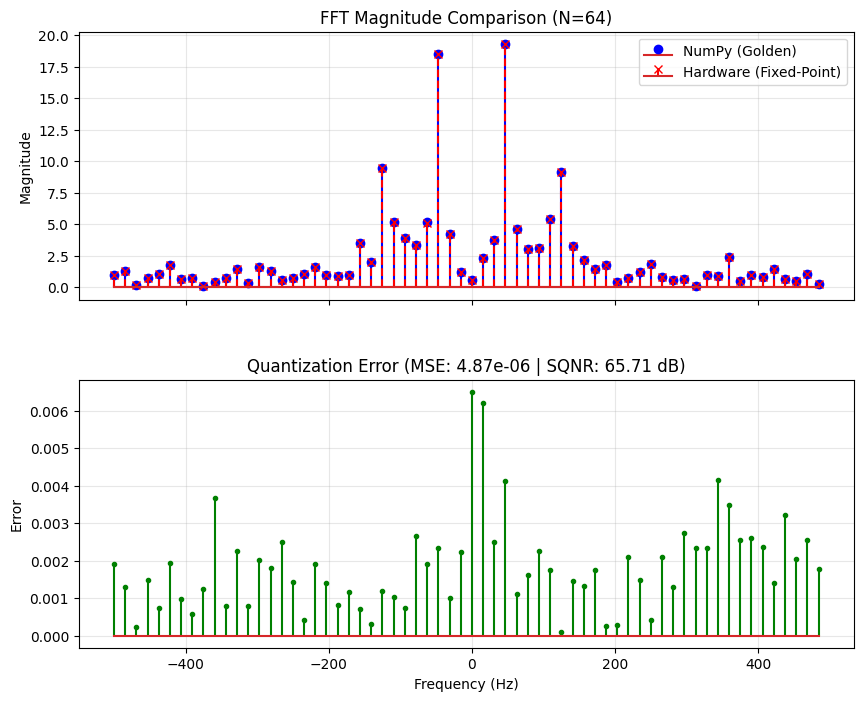

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.utils import capture
from fft_utils import run_sim, analyze_fft_performance
# 1. Generate a test signal 
N = 64
fs = 1000
t = np.arange(N) / fs

input_signal = (0.6 * np.sin(2 * np.pi * 50 * t) + 
                0.4 * np.sin(2 * np.pi * 120 * t)).astype(complex)

input_signal += 0.1 * (np.random.randn(N) + 1j*np.random.randn(N))

# 2. Run Hardware Simulation Silently
print("Running Hardware Simulation...")
with capture.capture_output() as cap:
    try:
        # We assume run_sim returns: hw_sig, blk_exp, cycles
        hw_sig, hw_exp, cycles = run_sim(input_signal)
        sim_success = True
    except Exception as e:
        sim_success = False
        print(f"Error: {e}")

if sim_success:
    # 3. Analyze Performance
    stats = analyze_fft_performance(input_signal, hw_sig, hw_exp)
    
    # 4. Professional Plotting for Report
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    plt.subplots_adjust(hspace=0.3)

    freqs = np.fft.fftfreq(N, 1/fs)
    
    # Top Plot: Magnitude Comparison
    ax1.stem(freqs, np.abs(stats['golden']), linefmt='b-', markerfmt='bo', label='NumPy (Golden)')
    ax1.stem(freqs, np.abs(hw_sig)*(2**hw_exp), linefmt='r--', markerfmt='rx', label='Hardware (Fixed-Point)')
    ax1.set_title(f"FFT Magnitude Comparison (N={N})")
    ax1.set_ylabel("Magnitude")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Bottom Plot: Error Distribution
    ax2.stem(freqs, np.abs(stats['error_vec']), linefmt='g-', markerfmt='g.', label='Error Magnitude')
    ax2.set_title(f"Quantization Error (MSE: {stats['mse']:.2e} | SQNR: {stats['sqnr_db']:.2f} dB)")
    ax2.set_ylabel("Error")
    ax2.set_xlabel("Frequency (Hz)")
    ax2.grid(True, alpha=0.3)

    print(f"✅ Success! Latency: {cycles} clock cycles.")
    print(f"📊 SQNR: {stats['sqnr_db']:.2f} dB (Higher is better)")
else:
    # If it failed, show the NVC logs so we can see why
    cap.show()